<a href="https://colab.research.google.com/github/shreyaghora/ArrhythmiaHub/blob/main/Code/Shap_lime(Best_4_Models).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lightgbm
!pip install catboost
!pip install xgboost
!pip install specificity
!pip install imbalanced-learn
!pip install lime
!pip install xlsxwriter

!pip install ipython-autotime
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9f0df531d681964f52a145fd3f8be094ff5e62fbc50943baede21a7adca9be84
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.2 MB/s eta 0:00:00
time: 342 µs (started: 2026-05-19 08:03:24 +00:00)


In [ ]:
import numpy as np
import pandas as pd
import time
import shap
import matplotlib.pyplot as plt

from scipy.stats import uniform
from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix, balanced_accuracy_score

time: 9.75 s (started: 2026-05-19 08:21:53 +00:00)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
time: 25 s (started: 2026-05-19 08:22:30 +00:00)


In [ ]:
df = pd.read_csv("INCART 2-lead Arrhythmia Database.csv")
df.head(50)

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
0,I01,N,163,165,0.069610,-0.083281,0.614133,-0.392761,0.047159,15,...,-0.023370,14,3,23,6,-0.023370,-0.011650,0.082608,0.101373,-0.183387
1,I01,N,165,166,-0.097030,0.597254,-0.078704,-0.078704,-0.137781,3,...,0.081637,15,5,27,7,0.081637,0.102992,0.191225,0.217544,-0.068248
2,I01,N,166,102,0.109399,0.680528,-0.010649,-0.010649,-0.720620,6,...,-0.148539,33,13,52,6,-0.148539,-0.060620,0.081080,0.204400,0.335172
3,I01,VEB,102,231,0.176376,0.256431,-0.101098,-0.707525,-0.101098,4,...,0.046898,21,9,34,4,0.046898,0.083728,0.279512,0.526785,0.450969
4,I01,N,231,165,0.585577,0.607461,-0.083499,-0.083499,-0.167858,3,...,-0.112552,32,5,43,6,-0.112552,0.012989,0.091491,0.134004,0.265232
5,I01,N,165,163,0.019637,-0.111671,0.613374,-0.416937,-0.108554,21,...,-0.088215,32,8,47,7,-0.088215,-0.001563,0.082968,0.136342,0.308107
6,I01,N,163,166,-0.156761,0.528148,-0.145137,-0.145137,-0.183749,2,...,0.066682,16,5,27,6,0.066682,0.084804,0.174772,0.224360,-0.011853
7,I01,N,166,161,-0.003887,0.216949,1.120258,0.164411,-0.725340,33,...,-0.198099,3,4,14,7,-0.198099,-0.198099,-0.322683,-0.322683,-0.429821
8,I01,N,161,160,-0.006721,0.164998,0.601190,-0.307812,-0.035103,15,...,0.062813,14,9,29,6,0.062813,0.080551,0.159296,0.108512,-0.248600
9,I01,N,160,158,-0.187870,0.544414,-0.018564,-0.018564,-0.194883,5,...,0.127967,14,5,26,7,0.127967,0.147617,0.247298,0.264875,-0.032502


time: 1.25 s (started: 2026-05-19 08:22:58 +00:00)


In [ ]:
# # 3. Drop Feature
df.drop('record', axis=1, inplace=True)

df = df[df['type'] != 'Q']

# 5. Encode Target
df['type'] = df['type'].map({'F': 0, 'N': 1, 'SVEB': 2, 'VEB': 3});
X = df.drop('type', axis=1)
y = df['type']

feature_names = X.columns;

# 9. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Apply SMOTE
sm = SMOTE(random_state=42, k_neighbors=2)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# 8. SCALE DATA
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)


time: 2.49 s (started: 2026-05-19 08:23:00 +00:00)


In [ ]:
def hyper_parameter_tune(model, param_dist, X_train, y_train):

    search = RandomizedSearchCV(
          model,
          param_distributions=param_dist,
          n_iter=5,
          cv=5,
          refit='roc_auc',
          n_jobs=-1,
          random_state=42,
          return_train_score=False
          )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    print("Best parameters:", search.best_params_)
    print("Best CV accuracy: {:.4f}".format(search.best_score_))


    return best_model

time: 658 µs (started: 2026-05-19 08:23:02 +00:00)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score
)

from sklearn.model_selection import KFold
from sklearn.preprocessing import label_binarize

import numpy as np
import pandas as pd
import time


def evaluate_models(name, model, X, y):

    result = []

    print(f"\nTrain Model: {name}\n")

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    classes = np.unique(y)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Train
        start_time = time.time()

        model.fit(X_train, y_train)

        training_time = time.time() - start_time

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        acc = accuracy_score(y_test, y_pred)

        prec = precision_score(y_test,y_pred,average='weighted',zero_division=0)

        rec = recall_score(y_test,y_pred,average='weighted',zero_division=0)

        f1 = f1_score(y_test,y_pred,average='weighted',zero_division=0)

        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        mcc = matthews_corrcoef(y_test, y_pred)

        kappa = cohen_kappa_score(y_test, y_pred)

        try:
            y_prob = model.predict_proba(X_test)

            y_test_bin = label_binarize(y_test, classes=classes)

            auc = roc_auc_score(
                y_test_bin,
                y_prob,
                multi_class='ovr'
            )

        except:
            auc = np.nan

        result.append({
            "Classifier": name,
            "Fold": fold + 1,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "AUC": auc,
            "MCC": mcc,
            "Kappa": kappa,
            "Balanced Accuracy": balanced_acc,
            "Training Time (s)": training_time
        })

    return pd.DataFrame(result)

time: 2.24 ms (started: 2026-05-19 08:23:04 +00:00)


In [ ]:
#  SHAP EXPLAINABILITY
def shap_explain(model, explainer_type, X_test_scaled, feature_names, X_test = X_test):
  print("\n--- SHAP EXPLANATION ---")


  # Use TreeExplainer (since RandomForest is tree-based)
  explainer = explainer_type(model)

  # Compute SHAP values
  shap_values = explainer.shap_values(X_test_scaled)

  # -------------------------------
  # 1. GLOBAL FEATURE IMPORTANCE
  # -------------------------------
  plt.figure()
  shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="bar")

  # -------------------------------
  # 2. DETAILED SUMMARY PLOT
  # -------------------------------
  plt.figure()

  shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)
  plt.figure()

  # # -------------------------------
  # # 3. DEPENDENCE PLOT
  # # -------------------------------
  # # Change feature name as needed
  # shap.dependence_plot(
  #     feature_names[0],  # example feature
  #     shap_values,
  #     X_test_scaled,
  #     feature_names=feature_names # Provide feature names for clarity
  # )

  # # -------------------------------
  # # 4. LOCAL EXPLANATION (FORCE PLOT)
  # # -------------------------------
  # # Use expected value of class 1
  # expected_value = explainer.expected_value

  # plt.figure()
  # shap.force_plot(
  #     expected_value,
  #     shap_values[0], # shap_vals is now (num_samples, num_features), so shap_vals[0] is for the first sample
  #     X_test.iloc[0],
  #     matplotlib=True
  # )

time: 945 µs (started: 2026-05-19 08:23:08 +00:00)


In [ ]:
# LIME EXPLAINABILITY

def lime_explain(model, X_train_scaled, X_test_scaled, feature_names, num_samples=100):

    print("\n--- LIME EXPLANATION ---")

    from lime.lime_tabular import LimeTabularExplainer
    import numpy as np
    import pandas as pd

    X_train_np = X_train_scaled.to_numpy() if hasattr(X_train_scaled, "to_numpy") else X_train_scaled
    X_test_np = X_test_scaled.to_numpy() if hasattr(X_test_scaled, "to_numpy") else X_test_scaled


    lime_explainer = LimeTabularExplainer(
        training_data=X_train_np,
        feature_names=feature_names,
        class_names=model.classes_.astype(str) if hasattr(model, "classes_") else None,
        mode='classification'
    )


    # 1. LOCAL EXPLANATION

    print("\n--- LOCAL EXPLANATION ---")

    lime_exp = lime_explainer.explain_instance(
        X_test_np[0],
        model.predict_proba
    )

    lime_exp.show_in_notebook(show_table=True)

    # 2. GLOBAL EXPLANATION

    print("\n--- GLOBAL EXPLANATION (approx via sampling) ---")

    feature_importance = np.zeros(X_train_np.shape[1])


    indices = np.random.choice(len(X_test_np), min(num_samples, len(X_test_np)), replace=False)

    for i in indices:
        exp = lime_explainer.explain_instance(
            X_test_np[i],
            model.predict_proba,
            num_features=len(feature_names)
        )

        for feature, weight in exp.as_list():

            feature_index = next(
                (j for j, name in enumerate(feature_names) if name in feature),
                None
            )

            if feature_index is not None:
                feature_importance[feature_index] += abs(weight)

    # Normalize importance
    feature_importance /= len(indices)

    # Create dataframe
    global_lime = pd.DataFrame({
        "feature": feature_names,
        "importance": feature_importance
    }).sort_values(by="importance", ascending=False)

    print(global_lime)


time: 4.14 ms (started: 2026-05-19 08:23:11 +00:00)


In [ ]:
from lightgbm import LGBMClassifier

name = "LightGBM" # change as per model

# Model
model = LGBMClassifier(n_jobs=2, verbose=-1) # change as per model

# Parameters, change as per model
param_dist = {
        'n_estimators': [21, 51, 101],
        'learning_rate': [0.01, 0.05, 0.08],
        'num_leaves': [30, 50, 70],
        'max_depth': [-1, 5, 10],
        'subsample': [0.2, 0.5, 0.8],
        'colsample_bytree': [0.2, 0.5, 0.8]
    }

best_model = hyper_parameter_tune(model, param_dist, X_train_scaled, y_train_sm)

LightGBM = evaluate_models(name, best_model, X_train_scaled, y_train_sm)

LightGBM


Train Model: LightGBM



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,Classifier,Fold,Accuracy,Precision,Recall,F1,AUC,MCC,Kappa,Balanced Accuracy,Training Time (s)
0,LightGBM,1,0.995847,0.995848,0.995847,0.995845,0.999934,0.994464,0.994462,0.995838,56.014437
1,LightGBM,2,0.996274,0.996275,0.996274,0.996273,0.999951,0.995034,0.995032,0.996269,24.201820
2,LightGBM,3,0.995724,0.995727,0.995724,0.995723,0.999945,0.994301,0.994299,0.995733,24.415209
3,LightGBM,4,0.995887,0.995889,0.995887,0.995886,0.999926,0.994518,0.994516,0.995897,27.952126
4,LightGBM,5,0.995684,0.995685,0.995684,0.995682,0.999934,0.994246,0.994245,0.995669,24.246713
5,LightGBM,6,0.995602,0.995603,0.995602,0.995600,0.999934,0.994138,0.994136,0.995595,25.331151
6,LightGBM,7,0.995582,0.995586,0.995582,0.995581,0.999938,0.994112,0.994109,0.995596,20.548093
7,LightGBM,8,0.995928,0.995931,0.995928,0.995927,0.999944,0.994572,0.994571,0.995913,21.111623
8,LightGBM,9,0.996356,0.996360,0.996356,0.996355,0.999956,0.995143,0.995141,0.996363,24.533791
9,LightGBM,10,0.996274,0.996276,0.996274,0.996273,0.999961,0.995034,0.995032,0.996275,23.833752


time: 5min 10s (started: 2026-05-16 02:49:10 +00:00)



--- SHAP EXPLANATION ---


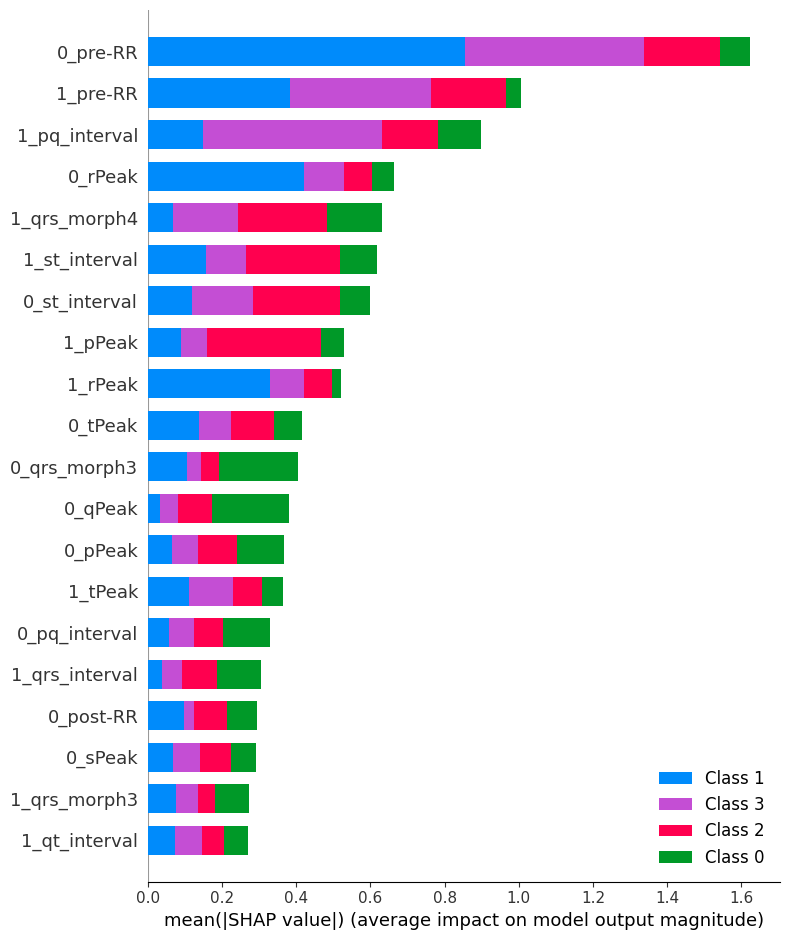

<Figure size 640x480 with 0 Axes>

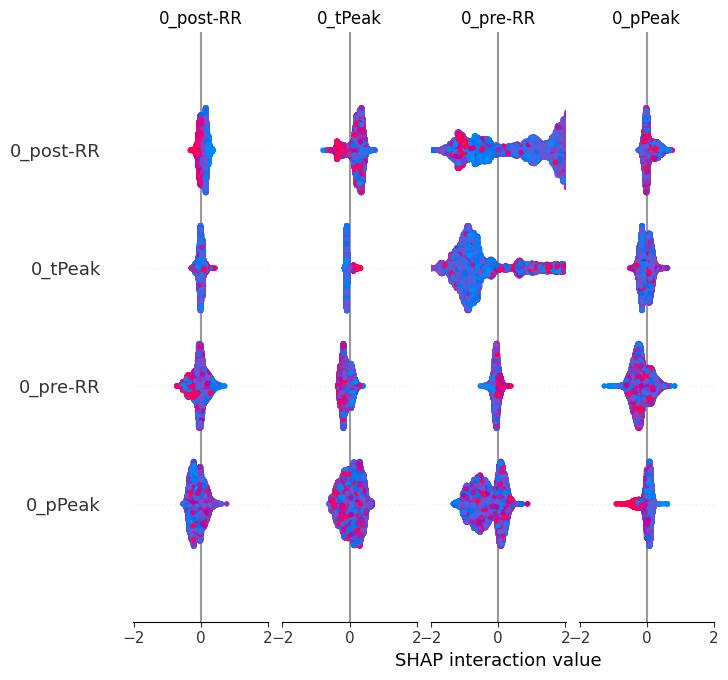

<Figure size 640x480 with 0 Axes>

time: 4min 22s (started: 2026-05-16 02:54:21 +00:00)


In [ ]:
shap_explain(best_model, shap.TreeExplainer, X_test_scaled, feature_names)

In [ ]:
lime_explain(best_model, X_train_scaled, X_test_scaled, feature_names)


--- LIME EXPLANATION ---

--- LOCAL EXPLANATION ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- GLOBAL EXPLANATION (approx via sampling) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

           feature  importance
0         0_pre-RR    0.259317
16        1_pre-RR    0.138197
24   1_pq_interval    0.077033
20         1_rPeak    0.039600
18         1_pPeak    0.034684
10   0_st_interval    0.032103
26   1_st_interval    0.030464
3          0_tPeak    0.030332
4          0_rPeak    0.028470
14    0_qrs_morph3    0.027879
21         1_sPeak    0.027201
1        0_post-RR    0.026686
17       1_post-RR    0.026510
7   0_qrs_interval    0.026347
27    1_qrs_morph0    0.026012
31    1_qrs_morph4    0.024733
25   1_qt_interval    0.023124
19         1_tPeak    0.022104
5          0_sPeak    0.020571
2          0_pPeak    0.020244
29    1_qrs_morph2    0.019165
15    0_qrs_morph4    0.018478
12    0_qrs_morph1    0.014533
22         1_qPeak    0.014167
30    1_qrs_morph3    0.014166
23  1_qrs_interval    0.012948
28    1_qrs_morph1    0.012152
9    0_qt_interval    0.010201
6          0_qPeak    0.009393
13    0_qrs_morph2    0.009115
8    0_pq_interval    0.006160
11    0_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from xgboost import XGBClassifier

name ="XGBoost"

#Model
model =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
            "max_depth": [3, 6]
}
best_model = hyper_parameter_tune(model, param_dist, X_train_scaled, y_train_sm)

XGBoost = evaluate_models(name, best_model, X_train_scaled, y_train_sm)
XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:03:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Best CV accuracy: 0.9988

Train Model: XGBoost



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:04:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:05:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:06:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:07:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Classifier,Fold,Accuracy,Precision,Recall,F1,AUC,MCC,Kappa,Balanced Accuracy,Training Time (s)
0,XGBoost,1,0.998717,0.998719,0.998717,0.998717,0.999969,0.998291,0.998290,0.998713,53.321095
1,XGBoost,2,0.998901,0.998901,0.998901,0.998900,0.999973,0.998535,0.998534,0.998898,53.340144
2,XGBoost,3,0.998962,0.998962,0.998962,0.998961,0.999960,0.998616,0.998616,0.998968,53.106362
3,XGBoost,4,0.998840,0.998840,0.998840,0.998839,0.999978,0.998453,0.998453,0.998845,50.341409
4,XGBoost,5,0.998840,0.998840,0.998840,0.998839,0.999970,0.998453,0.998453,0.998834,52.192216
5,XGBoost,6,0.998717,0.998718,0.998717,0.998717,0.999986,0.998290,0.998290,0.998710,53.038486
6,XGBoost,7,0.998534,0.998536,0.998534,0.998534,0.999972,0.998046,0.998045,0.998541,52.850798
7,XGBoost,8,0.998982,0.998982,0.998982,0.998982,0.999990,0.998643,0.998643,0.998974,53.357474
8,XGBoost,9,0.999063,0.999064,0.999063,0.999063,0.999990,0.998752,0.998751,0.999067,53.352210
9,XGBoost,10,0.999226,0.999226,0.999226,0.999226,0.999992,0.998969,0.998968,0.999227,51.083619


time: 22min 10s (started: 2026-05-16 23:51:21 +00:00)



--- SHAP EXPLANATION ---


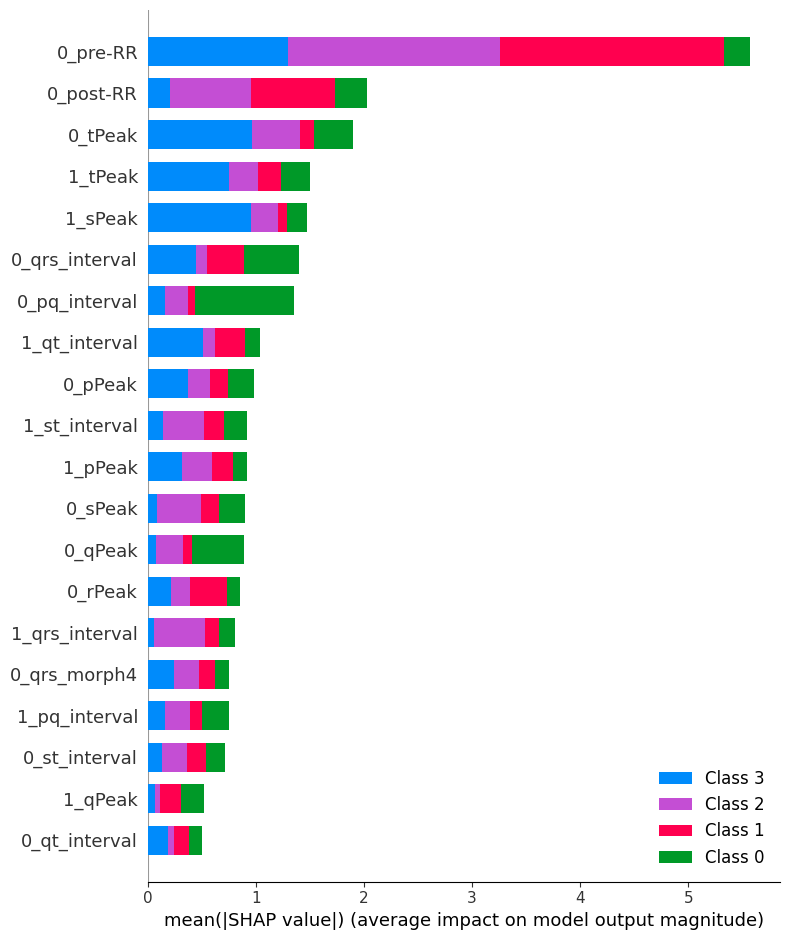

<Figure size 640x480 with 0 Axes>

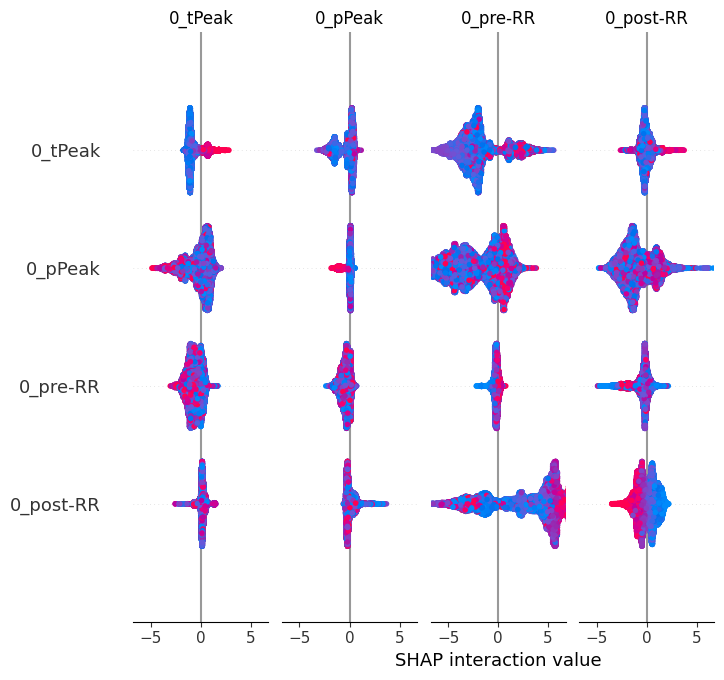

<Figure size 640x480 with 0 Axes>

time: 6min 14s (started: 2026-05-16 01:08:50 +00:00)


In [ ]:
shap_explain(best_model, shap.TreeExplainer, X_test_scaled, feature_names)

In [ ]:
lime_explain(best_model, X_train_scaled, X_test_scaled, feature_names)


--- LIME EXPLANATION ---

--- LOCAL EXPLANATION ---



--- GLOBAL EXPLANATION (approx via sampling) ---
           feature  importance
0         0_pre-RR    0.370431
1        0_post-RR    0.147962
21         1_sPeak    0.107601
3          0_tPeak    0.053780
25   1_qt_interval    0.052931
19         1_tPeak    0.052883
18         1_pPeak    0.050396
7   0_qrs_interval    0.042335
2          0_pPeak    0.033686
26   1_st_interval    0.025452
31    1_qrs_morph4    0.023797
9    0_qt_interval    0.021014
23  1_qrs_interval    0.020204
5          0_sPeak    0.019190
4          0_rPeak    0.019008
30    1_qrs_morph3    0.018895
24   1_pq_interval    0.018245
10   0_st_interval    0.018212
22         1_qPeak    0.017949
6          0_qPeak    0.016192
14    0_qrs_morph3    0.016149
15    0_qrs_morph4    0.013720
13    0_qrs_morph2    0.011957
28    1_qrs_morph1    0.011552
20         1_rPeak    0.010864
29    1_qrs_morph2    0.010836
8    0_pq_interval    0.009955
11    0_qrs_morph0    0.009551
17       1_post-RR    0.009231
27    1_qrs_morph0  

In [ ]:
from sklearn.tree import DecisionTreeClassifier


name="DecisionTree"

#Model
model = DecisionTreeClassifier()

# Search space
param_dist = {

    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

best_model = hyper_parameter_tune(model, param_dist, X_train_scaled, y_train_sm)

DecisionTree = evaluate_models(name, best_model, X_train_scaled, y_train_sm)
DecisionTree

Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best CV accuracy: 0.9958

Train Model: DecisionTree



,Classifier,Fold,Accuracy,Precision,Recall,F1,AUC,MCC,Kappa,Balanced Accuracy,Training Time (s)
0,DecisionTree,1,0.995093,0.995090,0.995093,0.995090,0.997642,0.993459,0.993458,0.995082,50.872642
1,DecisionTree,2,0.996254,0.996254,0.996254,0.996253,0.998207,0.995006,0.995005,0.996250,48.959619
2,DecisionTree,3,0.996254,0.996253,0.996254,0.996253,0.998354,0.995006,0.995005,0.996265,50.765121
3,DecisionTree,4,0.995582,0.995582,0.995582,0.995581,0.998009,0.994110,0.994109,0.995591,49.411748
4,DecisionTree,5,0.996111,0.996111,0.996111,0.996110,0.998194,0.994816,0.994815,0.996102,50.692788
5,DecisionTree,6,0.996050,0.996049,0.996050,0.996049,0.998193,0.994734,0.994734,0.996048,50.443776
6,DecisionTree,7,0.996010,0.996008,0.996010,0.996008,0.998017,0.994680,0.994679,0.996026,50.064588
7,DecisionTree,8,0.996172,0.996172,0.996172,0.996172,0.998133,0.994897,0.994896,0.996158,50.778782
8,DecisionTree,9,0.995623,0.995622,0.995623,0.995622,0.997926,0.994164,0.994164,0.995630,49.824689
9,DecisionTree,10,0.996641,0.996641,0.996641,0.996640,0.998359,0.995522,0.995521,0.996639,49.678005


time: 19min 4s (started: 2026-05-17 00:13:32 +00:00)


time: 19min 4s (started: 2026-05-17 00:13:32 +00:00)



--- SHAP EXPLANATION ---


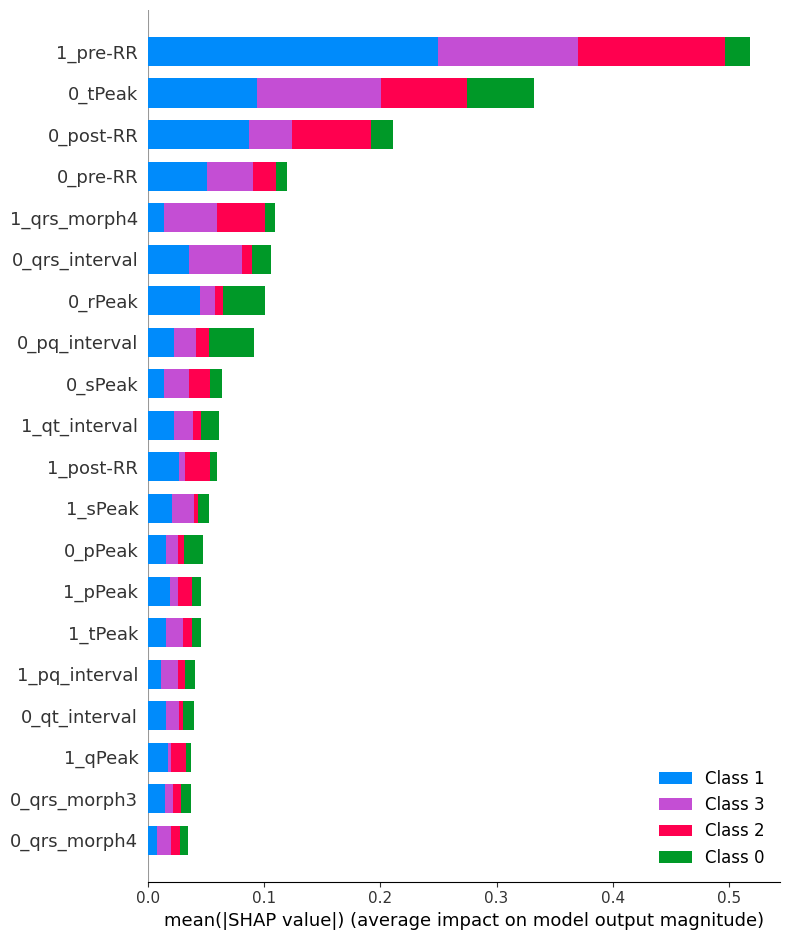

<Figure size 640x480 with 0 Axes>

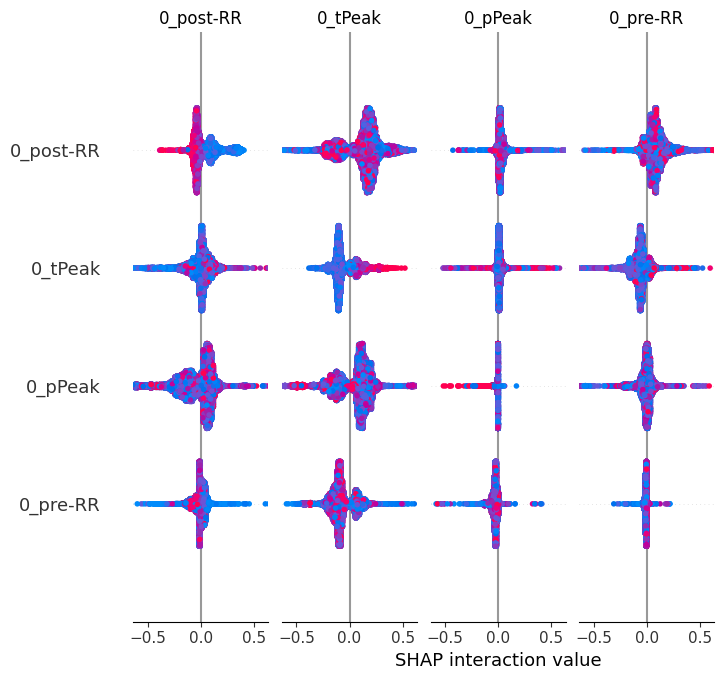

<Figure size 640x480 with 0 Axes>

time: 1min 51s (started: 2026-05-16 00:40:11 +00:00)


In [ ]:
shap_explain(best_model, shap.TreeExplainer, X_test_scaled, feature_names)

In [ ]:
lime_explain(best_model, X_train_scaled, X_test_scaled, feature_names)


--- LIME EXPLANATION ---

--- LOCAL EXPLANATION ---



--- GLOBAL EXPLANATION (approx via sampling) ---
           feature  importance
16        1_pre-RR    0.159769
1        0_post-RR    0.078669
0         0_pre-RR    0.075588
3          0_tPeak    0.069985
7   0_qrs_interval    0.032629
19         1_tPeak    0.030395
5          0_sPeak    0.029662
10   0_st_interval    0.025551
21         1_sPeak    0.025288
25   1_qt_interval    0.023916
17       1_post-RR    0.021189
31    1_qrs_morph4    0.019686
24   1_pq_interval    0.019580
18         1_pPeak    0.019384
8    0_pq_interval    0.019378
15    0_qrs_morph4    0.019221
2          0_pPeak    0.018966
14    0_qrs_morph3    0.016780
11    0_qrs_morph0    0.014723
23  1_qrs_interval    0.014387
22         1_qPeak    0.013558
27    1_qrs_morph0    0.013393
26   1_st_interval    0.013330
9    0_qt_interval    0.013289
13    0_qrs_morph2    0.013132
6          0_qPeak    0.012952
4          0_rPeak    0.012854
30    1_qrs_morph3    0.012675
28    1_qrs_morph1    0.012559
20         1_rPeak  

In [ ]:
from sklearn.ensemble import RandomForestClassifier

name = "Random Forest"

# Model
model = RandomForestClassifier(n_jobs=-1,
    random_state=42
)

# Parameters
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

best_model = hyper_parameter_tune(model, param_dist, X_train_scaled, y_train_sm)

Random_Forest = evaluate_models(name, best_model, X_train_scaled, y_train_sm)
Random_Forest

,Classifier,Fold,Accuracy,Precision,Recall,F1,AUC,MCC,Kappa,Balanced Accuracy,Training Time (s)
0,Random Forest,1,0.988558,0.988653,0.988558,0.988562,0.999690,0.984773,0.984744,0.988541,240.456005
1,Random Forest,2,0.988192,0.988303,0.988192,0.988200,0.999683,0.984287,0.984256,0.988184,239.989493
2,Random Forest,3,0.988029,0.988139,0.988029,0.988038,0.999688,0.984068,0.984038,0.988014,237.088522
3,Random Forest,4,0.987662,0.987751,0.987662,0.987667,0.999691,0.983576,0.983549,0.987669,237.929663
4,Random Forest,5,0.986726,0.986859,0.986726,0.986735,0.999644,0.982338,0.982300,0.986686,241.613954
5,Random Forest,6,0.987255,0.987360,0.987255,0.987262,0.999629,0.983037,0.983007,0.987257,243.219578
6,Random Forest,7,0.987621,0.987739,0.987621,0.987631,0.999607,0.983528,0.983495,0.987645,240.266899
7,Random Forest,8,0.987540,0.987664,0.987540,0.987547,0.999623,0.983423,0.983386,0.987559,240.423835
8,Random Forest,9,0.987886,0.988016,0.987886,0.987896,0.999692,0.983885,0.983848,0.987904,237.978543
9,Random Forest,10,0.988354,0.988460,0.988354,0.988361,0.999706,0.984503,0.984472,0.988361,240.936251


time: 37.4 ms (started: 2026-05-19 08:40:50 +00:00)



--- SHAP EXPLANATION ---


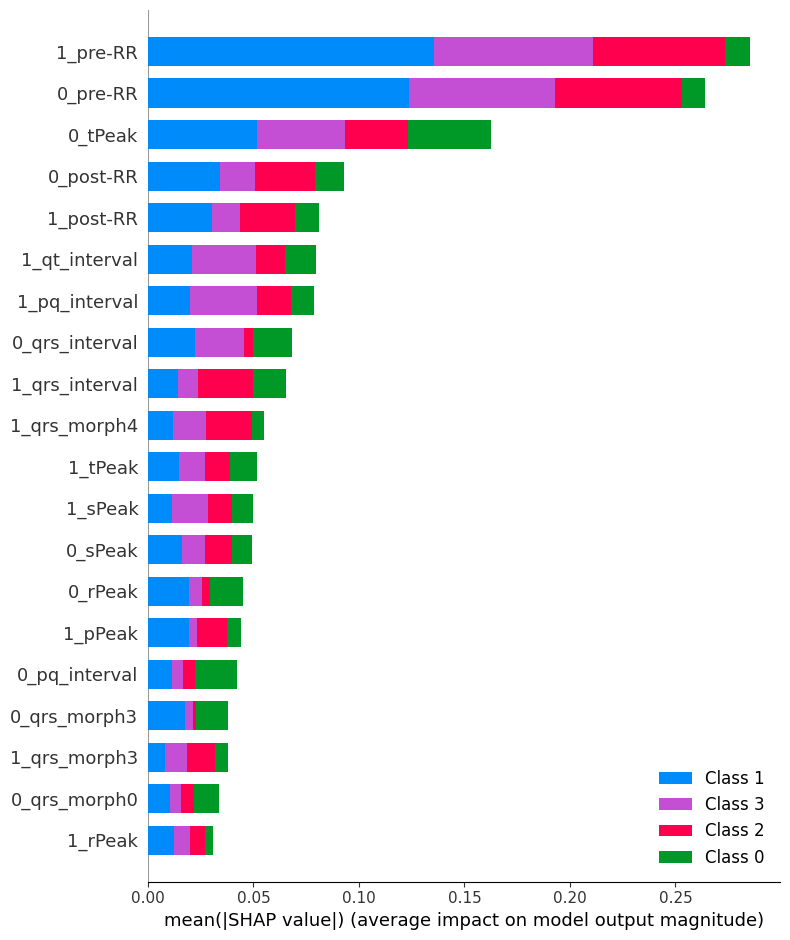

<Figure size 640x480 with 0 Axes>

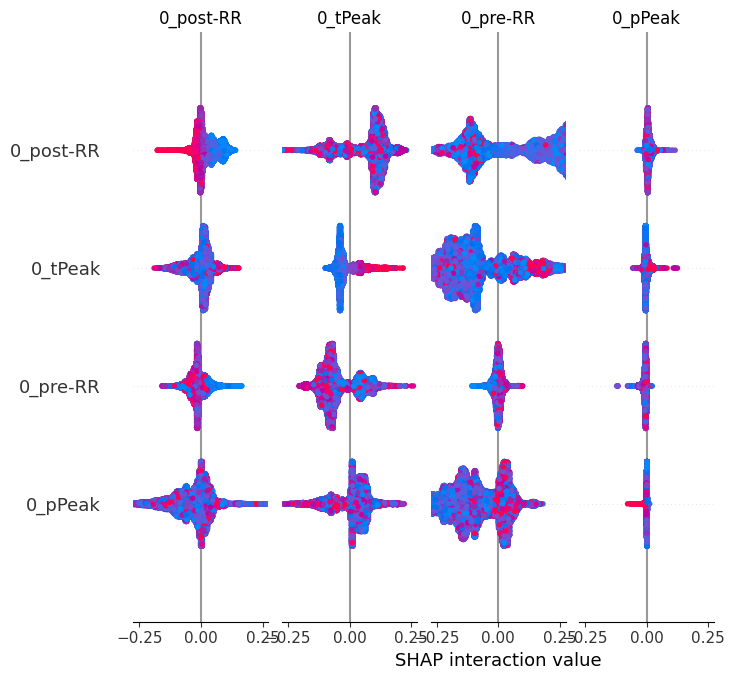

<Figure size 640x480 with 0 Axes>

time: 16min 32s (started: 2026-05-16 07:49:21 +00:00)


In [ ]:
shap_explain(best_model, shap.TreeExplainer, X_test_scaled, feature_names)

In [ ]:
lime_explain(best_model, X_train_scaled, X_test_scaled, feature_names)


--- LIME EXPLANATION ---

--- LOCAL EXPLANATION ---



--- GLOBAL EXPLANATION (approx via sampling) ---
           feature  importance
16        1_pre-RR    0.128315
0         0_pre-RR    0.118864
3          0_tPeak    0.060363
1        0_post-RR    0.045728
17       1_post-RR    0.037544
25   1_qt_interval    0.024457
24   1_pq_interval    0.018337
5          0_sPeak    0.015481
21         1_sPeak    0.014217
18         1_pPeak    0.014092
19         1_tPeak    0.013047
7   0_qrs_interval    0.011104
22         1_qPeak    0.008749
14    0_qrs_morph3    0.008723
27    1_qrs_morph0    0.008664
28    1_qrs_morph1    0.008438
4          0_rPeak    0.007962
23  1_qrs_interval    0.007839
20         1_rPeak    0.007256
26   1_st_interval    0.007020
8    0_pq_interval    0.005825
15    0_qrs_morph4    0.005481
2          0_pPeak    0.005040
10   0_st_interval    0.005026
29    1_qrs_morph2    0.004833
13    0_qrs_morph2    0.004506
12    0_qrs_morph1    0.004481
9    0_qt_interval    0.004407
31    1_qrs_morph4    0.004154
11    0_qrs_morph0  